In [23]:
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(" Path to dataset files:", path)

files = [
'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
'Monday-WorkingHours.pcap_ISCX.csv',
'Friday-WorkingHours-Morning.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
'Tuesday-WorkingHours.pcap_ISCX.csv',
'Wednesday-workingHours.pcap_ISCX.csv',
'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
       
       ]

dfs = []

for file in files:
    df = pd.read_csv(os.path.join(path, file))
    df.columns = df.columns.str.strip()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)
print(data['Label'].value_counts())

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1
(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]

data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

from  xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454264
           1       0.93      0.75      0.83       391
           2       1.00      1.00      1.00     25605
           3       1.00      1.00      1.00      2058
           4       1.00      1.00      1.00     46025
           5       0.99      0.99      0.99      1100
           6       1.00      0.99      0.99      1159
           7       1.00      1.00      1.00      1587
           8       1.00      1.00      1.00         3
           9       1.00      0.62      0.77         8
          10       0.99      1.00      1.00     31761
          11       1.00      1.00      1.00      1179
          12       0.75      0.83      0.78       301
          13       1.00      0.60      0.75         5
          14       0.48      0.35      0.40       130

    accuracy                           1.00    565576
   macro avg       0.94      0.88      0.90    565576
weighted avg      

15
1.0
[8.3894273e-03 3.1688545e-04 2.9142458e-02 1.8555960e-02 2.0556038e-02
 1.3147694e-02 1.8098271e-02 1.2072812e-02 2.1845587e-03 3.3163608e-03
 2.8897441e-04 1.0984514e-03 6.0167756e-02 1.2504978e-01 7.2904141e-03
 4.6817135e-04 4.6308613e-03 2.7645292e-04 1.3608093e-04 2.9776429e-04
 3.1809267e-04 1.4584148e-04 1.0779540e-04 5.7246239e-04 5.9637328e-04
 1.2819380e-04 2.8425178e-03 6.5184606e-04 7.2575576e-04 3.4719036e-04
 2.0900939e-03 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.0497123e-03
 6.9863796e-02 2.1513010e-04 1.5916970e-02 1.7182827e-03 3.2365531e-02
 2.0835998e-03 7.9568010e-04 1.3551113e-02 0.0000000e+00 0.0000000e+00
 9.5444709e-02 1.7928086e-04 9.6220443e-05 0.0000000e+00 0.0000000e+00
 5.6841713e-04 7.4464522e-02 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 8.5945107e-04 3.7500153e-03
 8.2016475e-02 5.4971525e-03 6.0016341e-03 6.5791495e-03 1.8530118e-04

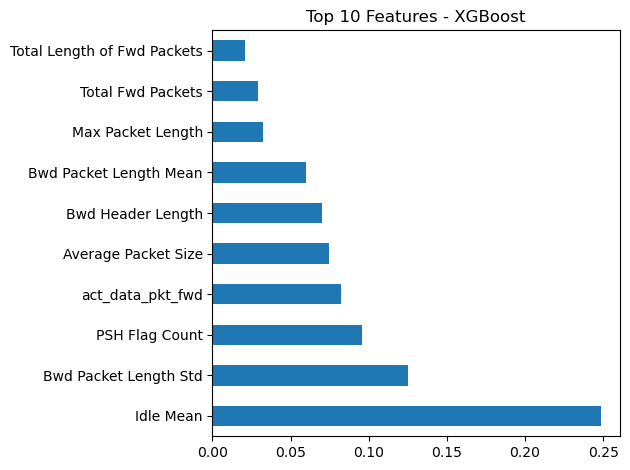

In [26]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()